In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve,accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.drop(columns=['Name','PassengerId', 'Cabin', 'Ticket'], inplace=True)

In [6]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/var/folders/k9/8xshsk5d1hvbqhcdpjb7jb400000gn/T/ipykernel_52796/1542921.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [7]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [8]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df=pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [11]:
#feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('Survived', axis=1))
X = pd.DataFrame(scaled_features, columns=df.drop('Survived', axis =1).columns)
y= df['Survived']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [13]:
model = LogisticRegression()
params = {
    'C': [0.01,0.1,1,1.0],
    'solver': ['liblinear', 'lbfgs']
}
grid = GridSearchCV(model, param_grid=params, cv=5, scoring='accuracy')
grid.fit(X_train,y_train)
best_model = grid.best_estimator_

In [14]:
y_pred= best_model.predict(X_test)

print("confusion matrix", confusion_matrix(y_test,y_pred))
print('class report:' ,classification_report(y_test,y_pred))
print('accuracy:', accuracy_score(y_test,y_pred))

confusion matrix [[143  14]
 [ 39  72]]
class report:               precision    recall  f1-score   support

           0       0.79      0.91      0.84       157
           1       0.84      0.65      0.73       111

    accuracy                           0.80       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.80      0.80       268

accuracy: 0.8022388059701493


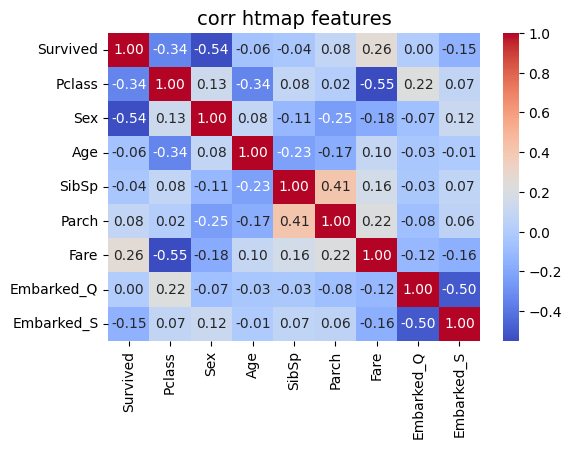

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('corr htmap features', fontsize=14)
plt.show()


/var/folders/k9/8xshsk5d1hvbqhcdpjb7jb400000gn/T/ipykernel_52796/2711347091.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='muted')


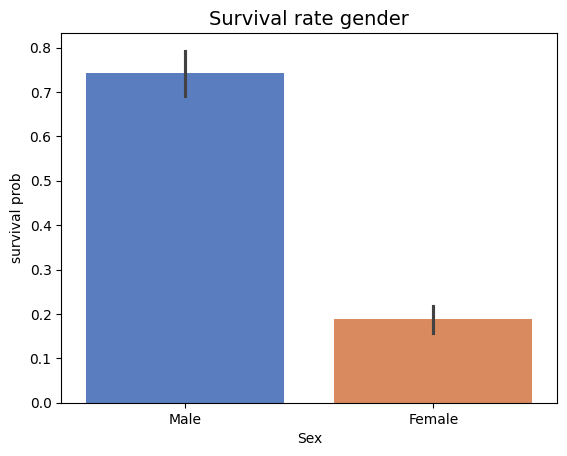

In [16]:
sns.barplot(x='Sex', y='Survived', data=df, palette='muted')
plt.xticks([0,1], ['Male', 'Female'])
plt.title('Survival rate gender', fontsize=14) 
plt.ylabel("survival prob")
plt.show()

TypeError: title() missing 1 required positional argument: 'label'

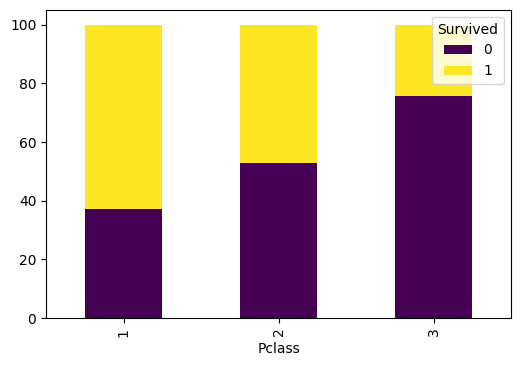

In [18]:
ct=pd.crosstab(df['Pclass'], df['Survived'], normalize='index')*100
ct.plot(kind='bar', stacked=True,colormap='viridis', figsize=(6,4))
plt.title()
plt.ylabel()
plt.xlabel()
plt.legend(['did not survive','survived'])
plt.grid(axis='y')
plt.show()